# IY031 - Visualise SimCLR Embeddings for TF @ Condition

In [1]:
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycatch22
import torch
from pathlib import Path
from matplotlib.patches import Patch
from IPython.display import display
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
from models.ssl_transformer import SSL_Transformer

RANDOM_STATE = 42

EXCLUDED_TFS = {"Empty", "Gcd6_Poss_Mix", "Sse2_Poss_Mix"}

# Fixed 12-class selection: TF identity only (conditions pooled), matching IY021 sanity-check panel
# Names as they appear in the metadata (title-case)
FIXED_TFS = {"Opi1", "Msn2", "Yox1", "Tea1", "Rox1", "Sok2", "Cup9", "Spt15", "Cbf1", "Stb5", "Cin5", "Rsc3"}

IY031_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY031")
IY008_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008")
EXP_DIR       = Path("/home/ianyang/stochastic_simulations/experiments")
SS_DATA_DIR   = IY008_DIR / "4_transformed_exp_time_series_NEW"
FULL_DATA_DIR = IY008_DIR / "5_FULL_transformed_exp_time_series_NEW"
META_PATH     = IY008_DIR / "NEW_data_metadata.csv"
META_COLS     = ["id", "group", "experiment"]

FILE_RE = re.compile(r"^(\d+)_group_(.+?)_(GFP|mCherry)_time_series$")
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif", "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")
print(f"Device: {DEVICE}")

Device: cuda


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Metadata & Label Lookup

In [2]:
metadata = pd.read_csv(META_PATH)
metadata["exp_id"]   = metadata["exp_id"].astype(str)
metadata["group_id"] = metadata["group_id"].astype(str)

LABEL_LOOKUP = {
    (row.exp_id, row.group_id, row.channel): (row.tf, row.condition)
    for _, row in metadata.iterrows()
    if row.tf not in EXCLUDED_TFS
}

print(f"Metadata entries: {len(metadata)}  (after excluding noisy TFs: {len(LABEL_LOOKUP)})")
print("Unique conditions:", sorted({v[1] for v in LABEL_LOOKUP.values()}))


Metadata entries: 639  (after excluding noisy TFs: 636)
Unique conditions: ['0% glucose', 'low N₂']


## 2. Load Datasets

In [3]:
from utils.experimental_time_series import load_labelled_time_series_csvs
"""Scan data_dir for time-series CSVs; assign TF@condition labels via metadata."""

print("=" * 70)
print(f"STEADY-STATE  ({SS_DATA_DIR.name})")
print("=" * 70)
ss_ts_raw, ss_label_strs = load_labelled_time_series_csvs(
        data_dir=SS_DATA_DIR,
        file_re=FILE_RE,
        label_lookup=LABEL_LOOKUP,
        meta_cols=META_COLS,
        label_fn=lambda tf, condition: tf,
        verbose=False,
    )
print(f"Loaded {len(ss_ts_raw)} files, {len(ss_label_strs)} total cells  ({SS_DATA_DIR.name})")

print("=" * 70)
print(f"FULL  ({FULL_DATA_DIR.name})")
print("=" * 70)
full_ts_raw, full_label_strs = load_labelled_time_series_csvs(
        data_dir=FULL_DATA_DIR,
        file_re=FILE_RE,
        label_lookup=LABEL_LOOKUP,
        meta_cols=META_COLS,
        label_fn=lambda tf, condition: tf,
        verbose=False,
    )
print(f"Loaded {len(full_ts_raw)} files, {len(full_label_strs)} total cells  ({FULL_DATA_DIR.name})")


STEADY-STATE  (4_transformed_exp_time_series_NEW)


Loaded 598 files, 20770 total cells  (4_transformed_exp_time_series_NEW)
FULL  (5_FULL_transformed_exp_time_series_NEW)


Loaded 636 files, 22038 total cells  (5_FULL_transformed_exp_time_series_NEW)


## 3. Class Selection

In [4]:
def print_class_summary(label_strs, kept_tfs, dataset_name):
    counts = pd.Series(label_strs).value_counts().sort_index()
    kept   = sorted(kept_tfs)
    print(f"{dataset_name} -- {len(counts)} total TF classes, {len(label_strs)} total cells")
    print(f"  Fixed {len(kept)}-class selection (IY021 sanity check):")
    for cls in kept:
        cnt = counts.get(cls, 0)
        print(f"  {cls:20s}: {cnt:5d}")
    missing = [c for c in kept if counts.get(c, 0) == 0]
    if missing:
        print(f"  WARNING: TFs with no data: {missing}")
    print(f"  -> Using {len(kept)} classes")
    print(f"  Chance: 1/{len(kept)} = {1/len(kept):.4f}")
    return kept


print()
ss_kept_classes   = print_class_summary(ss_label_strs,   FIXED_TFS, "Steady-state")
print()
full_kept_classes = print_class_summary(full_label_strs, FIXED_TFS, "Full")


Steady-state -- 138 total TF classes, 20770 total cells
  Fixed 12-class selection (IY021 sanity check):
  Cbf1                :   365
  Cin5                :   275
  Cup9                :   250
  Msn2                :   507
  Opi1                :   495
  Rox1                :   402
  Rsc3                :   338
  Sok2                :   289
  Spt15               :   317
  Stb5                :   251
  Tea1                :   316
  Yox1                :   426
  -> Using 12 classes
  Chance: 1/12 = 0.0833

Full -- 140 total TF classes, 22038 total cells
  Fixed 12-class selection (IY021 sanity check):
  Cbf1                :   365
  Cin5                :   275
  Cup9                :   250
  Msn2                :   507
  Opi1                :   495
  Rox1                :   402
  Rsc3                :   338
  Sok2                :   289
  Spt15               :   317
  Stb5                :   251
  Tea1                :   316
  Yox1                :   426
  -> Using 12 classes
  Chance

## 4. Preprocessing

In [5]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from utils.processing.pipeline import prepare_dataset

print("--- Steady-state ---")
ss = prepare_dataset(ss_ts_raw, ss_label_strs, ss_kept_classes, "Steady-state")
print()
print("--- Full ---")
full = prepare_dataset(full_ts_raw, full_label_strs, full_kept_classes, "Full")

--- Steady-state ---
Steady-state: 4231 cells × 17 tp, 12 classes, NaN remaining: 0
  Balancing to 250 cells/class
  Train: 2400  |  Test: 600

--- Full ---
Full: 4231 cells × 24 tp, 12 classes, NaN remaining: 0
  Balancing to 250 cells/class
  Train: 2400  |  Test: 600


## 5. Metadata for Balanced Datasets

Reconstruct per-cell metadata (TF, condition, class label) aligned with `X_bal` from the integer labels returned by `prepare_dataset`.

In [6]:
ds_tags = {"Steady-state": "ss", "Full": "full"}
datasets = {"Steady-state": ss, "Full": full}

metadata_dict = {}
for ds_name, ds in datasets.items():
    class_names = ds["class_names"]
    y_bal = ds["y_bal"]
    # Class names are bare TF names (label_fn=lambda tf, condition: tf),
    # so class_name == tf; no condition column available.
    meta = pd.DataFrame({
        "class_name": [class_names[y] for y in y_bal],
        "label": y_bal,
        "tf": [class_names[y] for y in y_bal],
    })
    metadata_dict[ds_name] = meta
    print(f"\n{ds_name}:")
    display(meta["class_name"].value_counts().sort_index().rename("n").to_frame())


Steady-state:


,n
class_name,
Cbf1,250
Cin5,250
Cup9,250
Msn2,250
Opi1,250
Rox1,250
Rsc3,250
Sok2,250
Spt15,250



Full:


,n
class_name,
Cbf1,250
Cin5,250
Cup9,250
Msn2,250
Opi1,250
Rox1,250
Rsc3,250
Sok2,250
Spt15,250


## 6. Feature Extraction

Three representations are extracted per dataset:

- **Raw time-series features**: traces scaled with `StandardScaler`.
- **catch22**: 22 canonical time-series features per cell (single channel), scaled.
- **SimCLR**: frozen transformer backbone embeddings from the best IY031 checkpoint (IY023-global b64 D16, acc = 0.30 on steady-state).

A SimCLR + RBF SVM decision-score representation is also computed to visualise classifier-level separation.

In [7]:
from utils.embeddings import load_simclr_model, encode_channel
from features.catch22 import extract_catch22

# Best overall checkpoint on IY031 steady-state (acc=0.297; IY031_NEW_tf_condition_ss_simclr_results.csv, row 0)
BEST_SIMCLR_CKPT = Path(
    "/home/ianyang/stochastic_simulations/experiments/EXP-26-IY023/"
    "IY023_simCLR_mixed_b64_lr0.01_L2_H4_D16_global_20260315_130449_model.pth"
)
simclr_model = load_simclr_model(BEST_SIMCLR_CKPT, DEVICE)
print(f"Loaded: {BEST_SIMCLR_CKPT.name}\n")

repr_matrices = {ds_name: {} for ds_name in datasets}

for ds_name, ds in datasets.items():
    X_bal = ds["X_bal"]
    X_norm = StandardScaler().fit_transform(X_bal)

    # Raw time-series features (batch-normalised traces as feature vectors)
    repr_matrices[ds_name]["Raw SVM features"] = StandardScaler().fit_transform(X_norm)

    # catch22: 22 canonical time-series features per cell (single channel)
    c22 = extract_catch22(X_bal, desc=f"catch22 {ds_name}", leave=False)
    c22 = c22.fillna(c22.median(numeric_only=True)).fillna(0.0)
    repr_matrices[ds_name]["catch22"] = StandardScaler().fit_transform(c22)

    # SimCLR: frozen single-channel encoder
    Z = encode_channel(simclr_model, X_norm, DEVICE)
    simclr_scaled = StandardScaler().fit_transform(Z)
    repr_matrices[ds_name]["SimCLR"] = simclr_scaled

    # SimCLR + SVM: per-class decision scores from an RBF SVM fitted on SimCLR embeddings
    labels = metadata_dict[ds_name]["label"].to_numpy()
    svm = SVC(kernel="rbf", C=1.0, gamma="scale", decision_function_shape="ovr", random_state=RANDOM_STATE)
    svm.fit(simclr_scaled, labels)
    scores = svm.decision_function(simclr_scaled)
    if scores.ndim == 1:
        scores = scores[:, None]
    repr_matrices[ds_name]["SimCLR + SVM scores"] = StandardScaler().fit_transform(scores)

    sizes = {k: v.shape for k, v in repr_matrices[ds_name].items()}
    print(f"{ds_name}: {sizes}")

Loaded: IY023_simCLR_mixed_b64_lr0.01_L2_H4_D16_global_20260315_130449_model.pth



catch22 Steady-state:   0%|          | 0/3000 [00:00<?, ?it/s]

catch22 Steady-state:  42%|████▏     | 1256/3000 [00:00<00:00, 12557.98it/s]

catch22 Steady-state:  84%|████████▍ | 2525/3000 [00:00<00:00, 12630.17it/s]

SimCLR encode:   0%|          | 0/12 [00:00<?, ?it/s]

...

catch22 Full:   0%|          | 0/3000 [00:00<?, ?it/s]

catch22 Full:  33%|███▎      | 994/3000 [00:00<00:00, 9932.48it/s]

catch22 Full:  69%|██████▊   | 2057/3000 [00:00<00:00, 10338.34it/s]

SimCLR encode:   0%|          | 0/12 [00:00<?, ?it/s]

Full: {'Raw SVM features': (3000, 24), 'catch22': (3000, 22), 'SimCLR': (3000, 16), 'SimCLR + SVM scores': (3000, 12)}


## 7. Discriminability D Scores and Clustering Metrics

D score (pairwise Cohen's d) measures class separation in the high-dimensional space before projection. ARI and NMI measure how well KMeans clusters (k = n_classes) align with the known class labels.

In [8]:
from utils.metrics import discriminability_d_score, clustering_agreement_metrics

d_score_dfs = {}
cluster_dfs = {}

for ds_name in datasets:
    labels = metadata_dict[ds_name]["label"].to_numpy()
    tag = ds_tags[ds_name]

    # Discriminability D scores
    d_rows = [
        {"representation": name, **discriminability_d_score(matrix, labels)}
        for name, matrix in repr_matrices[ds_name].items()
    ]
    d_df = pd.DataFrame(d_rows)
    d_score_dfs[ds_name] = d_df
    d_df.to_csv(IY031_DIR / f"IY031_NEW_{tag}_embedding_discriminability.csv", index=False)

    # Clustering agreement metrics (KMeans k=6 vs true labels)
    c_rows = [
        {"representation": name, **clustering_agreement_metrics(matrix, labels, RANDOM_STATE)}
        for name, matrix in repr_matrices[ds_name].items()
    ]
    c_df = pd.DataFrame(c_rows)
    cluster_dfs[ds_name] = c_df
    c_df.to_csv(IY031_DIR / f"IY031_NEW_{tag}_embedding_clustering_metrics.csv", index=False)

    print(f"\n{'=' * 55}")
    print(f"{ds_name} — Discriminability D scores")
    display(d_df.assign(
        D_score=lambda d: d["D_score"].map(lambda x: f"{x:.2g}"),
        mean_within_distance=lambda d: d["mean_within_distance"].map(lambda x: f"{x:.2g}"),
        mean_between_distance=lambda d: d["mean_between_distance"].map(lambda x: f"{x:.2g}"),
        pooled_distance_sd=lambda d: d["pooled_distance_sd"].map(lambda x: f"{x:.2g}"),
    ))
    print(f"\n{ds_name} — Clustering agreement metrics")
    display(c_df.assign(
        ARI=lambda d: d["ARI"].map(lambda x: f"{x:.2g}"),
        NMI=lambda d: d["NMI"].map(lambda x: f"{x:.2g}"),
        kmeans_inertia=lambda d: d["kmeans_inertia"].map(lambda x: f"{x:.2g}"),
    ))


Steady-state — Discriminability D scores


,representation,D_score,mean_within_distance,mean_between_distance,pooled_distance_sd,n_within_pairs,n_between_pairs
0,Raw SVM features,0.054,2.4,2.7,5,373500,4125000
1,catch22,0.089,5.9,6.1,1.8,373500,4125000
2,SimCLR,0.15,4.8,5.2,2.3,373500,4125000
3,SimCLR + SVM scores,0.33,4.3,4.8,1.4,373500,4125000



Steady-state — Clustering agreement metrics


,representation,ARI,NMI,n_clusters,kmeans_inertia
0,Raw SVM features,0.022,0.078,12,3.2e+03
1,catch22,0.019,0.053,12,2.6e+04
2,SimCLR,0.032,0.09,12,8.4e+03
3,SimCLR + SVM scores,0.063,0.13,12,7.9e+03



Full — Discriminability D scores


,representation,D_score,mean_within_distance,mean_between_distance,pooled_distance_sd,n_within_pairs,n_between_pairs
0,Raw SVM features,0.051,2.9,3.2,6,373500,4125000
1,catch22,0.083,5.9,6,1.9,373500,4125000
2,SimCLR,0.14,4.8,5.1,2.4,373500,4125000
3,SimCLR + SVM scores,0.32,4.3,4.8,1.4,373500,4125000



Full — Clustering agreement metrics


,representation,ARI,NMI,n_clusters,kmeans_inertia
0,Raw SVM features,0.021,0.077,12,5e+03
1,catch22,0.02,0.057,12,2.5e+04
2,SimCLR,0.027,0.093,12,9.2e+03
3,SimCLR + SVM scores,0.059,0.14,12,8.4e+03


## 8. Dimensionality Reduction

Three 2-D projections are computed for each representation and dataset:

- **PCA** — deterministic linear projection; fast, captures global variance.
- **t-SNE** — nonlinear neighbourhood embedding; good at revealing local cluster structure.
- **PHATE** — heat-diffusion manifold embedding (Moon et al., 2019); preserves both local and global structure, especially trajectory-like geometry in biological data.

In [9]:
from utils.embeddings import reduce_embeddings

# Use phate_knn=15 for this dataset (~3000 cells); knn=5 is too small and causes
# a disconnected PHATE graph. Rule of thumb: knn ~ sqrt(n_samples).
PHATE_KNN = 15

projections = {ds_name: {} for ds_name in datasets}
for ds_name in datasets:
    print(f"\n{ds_name}:")
    for repr_name, matrix in repr_matrices[ds_name].items():
        projections[ds_name][repr_name] = reduce_embeddings(
            matrix, repr_name, RANDOM_STATE, phate_knn=PHATE_KNN
        )


Steady-state:
Raw SVM features PCA explained variance: 0.97


    SGD-MDS may not have converged: stress changed by -1.6% in final iterations. Consider increasing n_iter or adjusting learning_rate.


catch22 PCA explained variance: 0.51


    SGD-MDS may not have converged: stress changed by 2.3% in final iterations. Consider increasing n_iter or adjusting learning_rate.


SimCLR PCA explained variance: 0.74


...

    SGD-MDS may not have converged: stress changed by -2.2% in final iterations. Consider increasing n_iter or adjusting learning_rate.


SimCLR PCA explained variance: 0.71


    SGD-MDS may not have converged: stress changed by 2.6% in final iterations. Consider increasing n_iter or adjusting learning_rate.


SimCLR + SVM scores PCA explained variance: 0.48


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/phate/phate.py:919: RuntimeWarning: Graph is disconnected with 2 connected components. This may indicate that your knn parameter (currently 15) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(


## 9. Scatter Plot Visualisation

Each point is one cell. Colour encodes the twelve TF classes (conditions are pooled in this dataset).

Grid: **rows** = projection method (PCA, t-SNE, PHATE); **columns** = representation (Raw SVM features, catch22, SimCLR, SimCLR + SVM scores). Metric annotations (D score, ARI, NMI) are computed in the high-dimensional space before projection and are identical across all projection rows.

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY031/IY031_NEW_ss_embedding_scatter.png


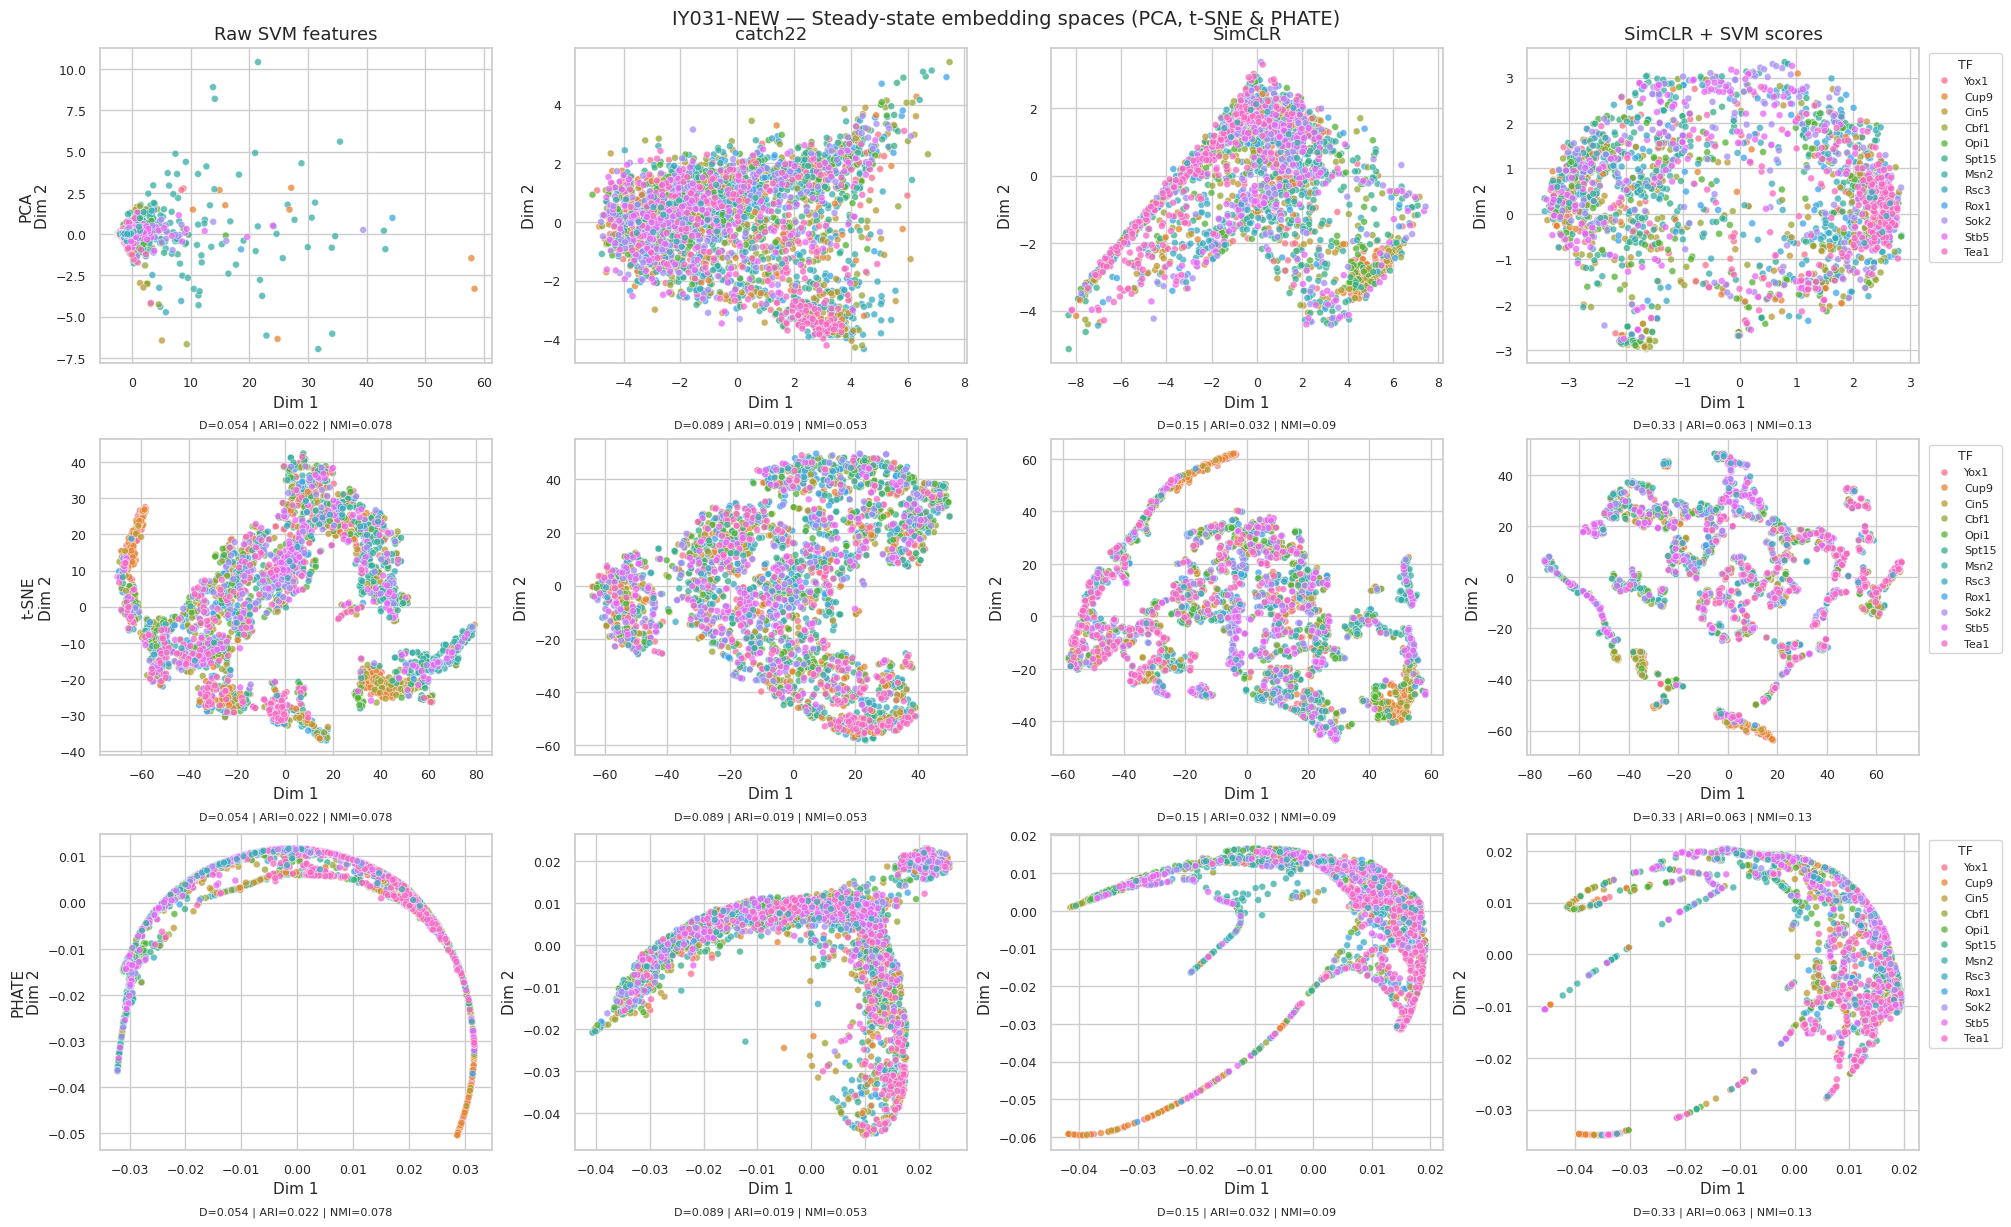

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY031/IY031_NEW_full_embedding_scatter.png


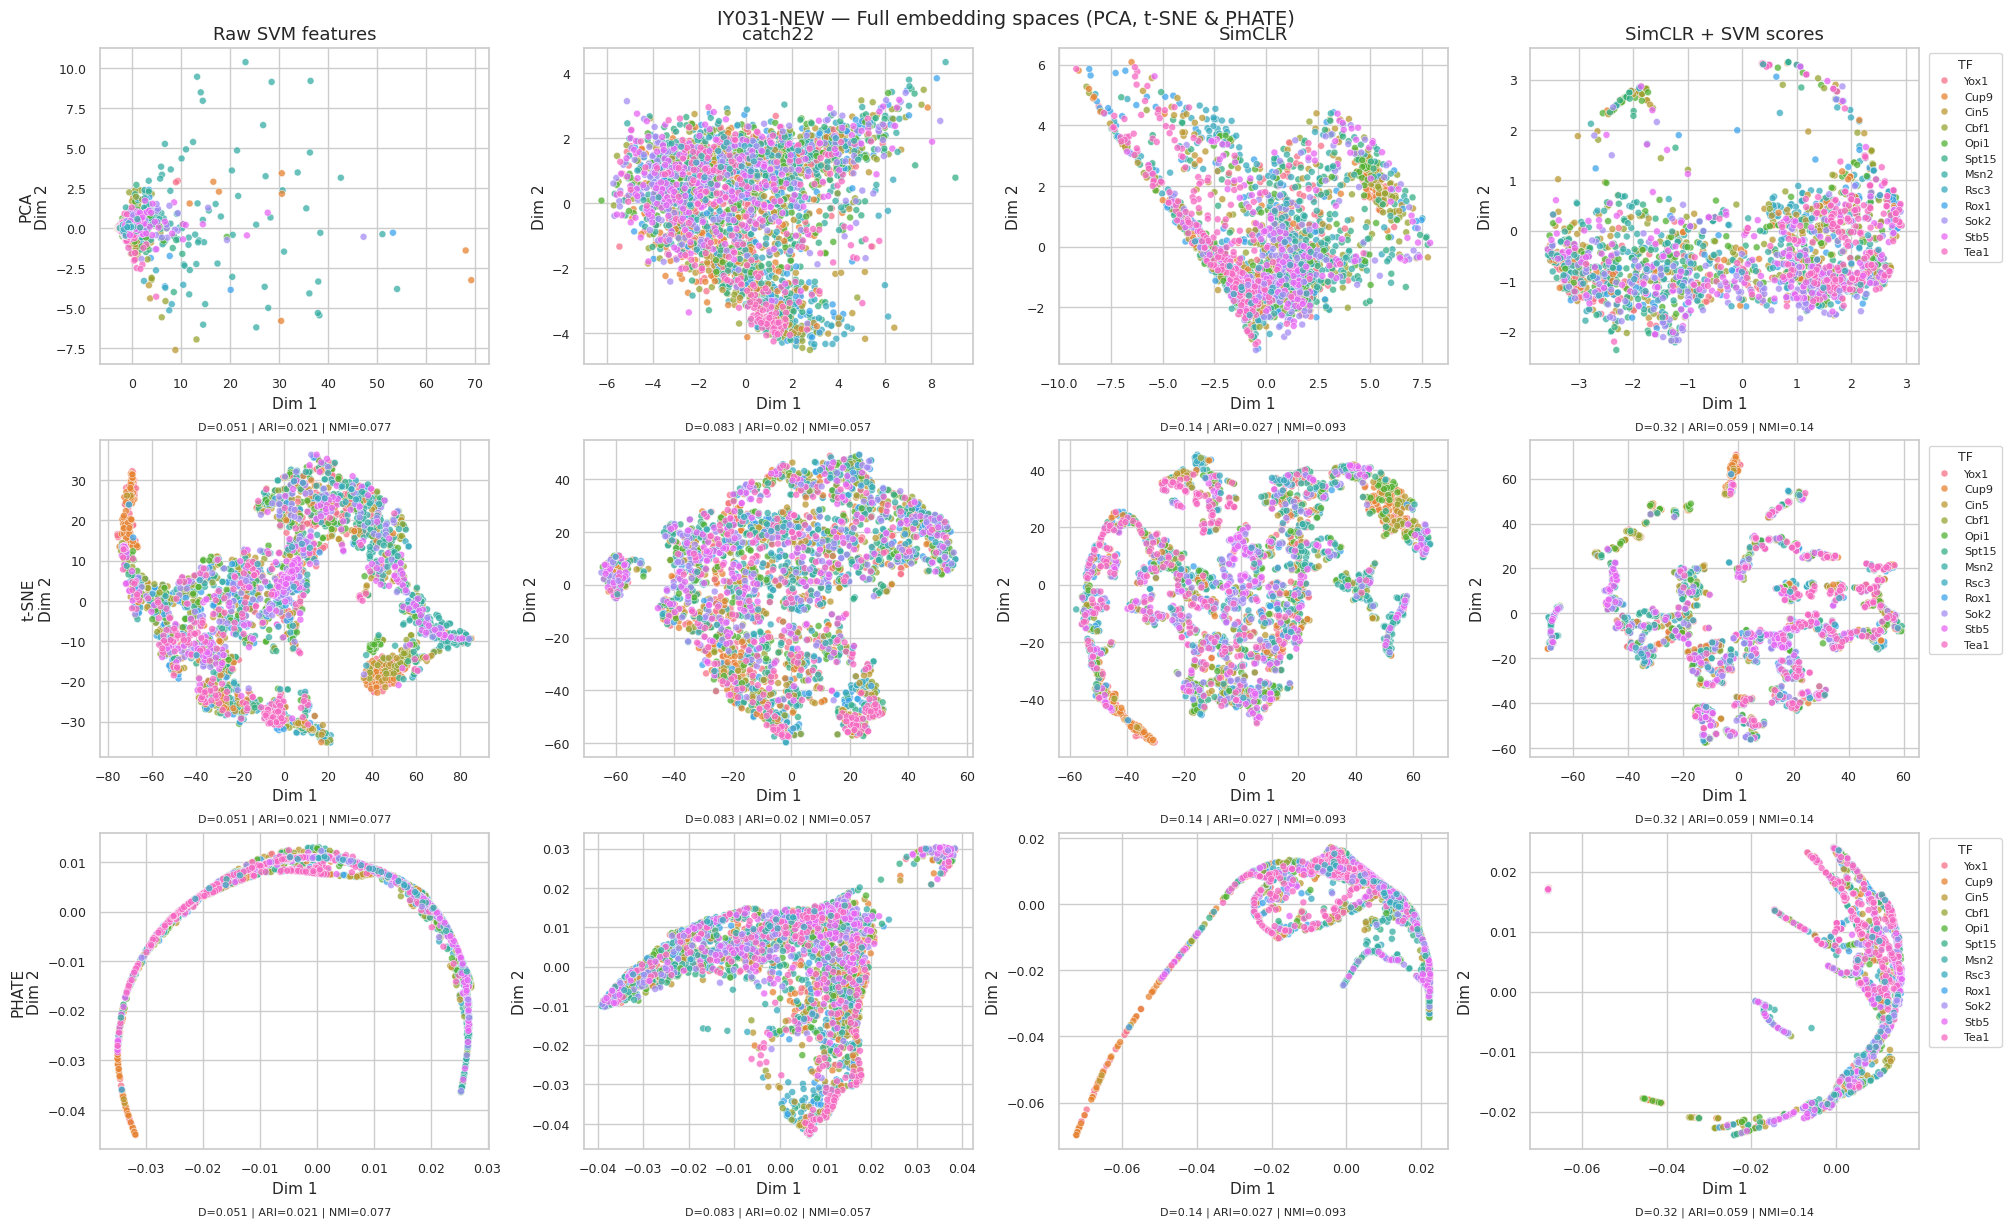

In [10]:
from utils.embeddings import projection_frame

representation_order = ["Raw SVM features", "catch22", "SimCLR", "SimCLR + SVM scores"]
method_order = ["PCA", "t-SNE", "PHATE"]
# 12 TF classes — husl gives 12 perceptually uniform colours.
n_classes = len(ss["class_names"])
palette = sns.color_palette("husl", n_classes)


def format_metric_value(v):
    """Format to 2 significant figures."""
    return np.format_float_positional(v, precision=2, unique=False, fractional=False, trim="k")


def metric_annotation(d_df, c_df, repr_name):
    """One-line D / ARI / NMI string for subplot annotation."""
    d_row = d_df.set_index("representation").loc[repr_name]
    c_row = c_df.set_index("representation").loc[repr_name]
    return (
        f"D={format_metric_value(d_row['D_score'])} | "
        f"ARI={format_metric_value(c_row['ARI'])} | "
        f"NMI={format_metric_value(c_row['NMI'])}"
    )


for ds_name, ds in datasets.items():
    meta = metadata_dict[ds_name]
    d_df = d_score_dfs[ds_name]
    c_df = cluster_dfs[ds_name]

    # Build one long plotting table for all representation × method combinations.
    plot_df = pd.concat(
        [
            projection_frame(projections[ds_name][r][m], meta, r, m)
            for r in representation_order
            for m in method_order
        ],
        ignore_index=True,
    )
    plot_df["TF"] = plot_df["tf"]

    n_rows, n_cols = len(method_order), len(representation_order)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        constrained_layout=True,
        squeeze=False,
    )

    for row, method in enumerate(method_order):
        for col, repr_name in enumerate(representation_order):
            ax = axes[row, col]
            df_sub = plot_df[
                (plot_df["representation"] == repr_name) & (plot_df["method"] == method)
            ]
            show_legend = col == n_cols - 1
            # style omitted — 12 TFs exhaust seaborn's distinct markers; colour alone suffices.
            sns.scatterplot(
                data=df_sub, x="x", y="y",
                hue="TF",
                palette=palette, s=25, alpha=0.75, ax=ax,
                legend=show_legend,
            )
            if row == 0:
                ax.set_title(repr_name, fontsize=13)
            ax.set_ylabel(f"{method}\nDim 2" if col == 0 else "Dim 2", fontsize=11)
            ax.set_xlabel("Dim 1", fontsize=11)
            ax.tick_params(labelsize=9)
            ax.text(
                0.5, -0.18, metric_annotation(d_df, c_df, repr_name),
                transform=ax.transAxes, ha="center", va="top", fontsize=8,
            )
            if show_legend:
                ax.legend(
                    bbox_to_anchor=(1.01, 1), loc="upper left",
                    fontsize=8, title="TF", title_fontsize=9,
                )

    fig.suptitle(f"IY031-NEW — {ds_name} embedding spaces (PCA, t-SNE & PHATE)", fontsize=14, y=1.01)
    tag = ds_tags[ds_name]
    out_path = IY031_DIR / f"IY031_NEW_{tag}_embedding_scatter.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()
    plt.close()

In [11]:
# Save projection coordinates for all representations and methods (PCA, t-SNE, PHATE)
for ds_name, ds in datasets.items():
    tag = ds_tags[ds_name]
    meta = metadata_dict[ds_name]
    frames = []
    for repr_name in repr_matrices[ds_name]:
        for method in ["PCA", "t-SNE", "PHATE"]:
            frame = projection_frame(projections[ds_name][repr_name][method], meta, repr_name, method)
            frames.append(frame)
    combined = pd.concat(frames, ignore_index=True)
    combined["TF & Condition"] = combined["class_name"]
    combined["TF"] = combined["tf"]
    out_path = IY031_DIR / f"IY031_NEW_{tag}_embedding_coordinates.csv"
    combined.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")
display(combined.head())

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY031/IY031_NEW_ss_embedding_coordinates.csv


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY031/IY031_NEW_full_embedding_coordinates.csv


,class_name,label,tf,x,y,representation,method,TF & Condition,TF
0,Yox1,11,Yox1,-2.811350,0.043580,Raw SVM features,PCA,Yox1,Yox1
1,Yox1,11,Yox1,-2.600466,0.068962,Raw SVM features,PCA,Yox1,Yox1
2,Yox1,11,Yox1,-2.532290,0.000404,Raw SVM features,PCA,Yox1,Yox1
3,Yox1,11,Yox1,-2.723634,0.047622,Raw SVM features,PCA,Yox1,Yox1
4,Yox1,11,Yox1,-2.692101,-0.032199,Raw SVM features,PCA,Yox1,Yox1
